In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib

from data.data_processor import DataProcessor
from data.splitter import SurvivalSplitter
from models.cox_model import CoxModel
from metrics.ibs import IBSMetric
from metrics.ibs_remain import IBSRemainMetric
from metrics.auprc import AUPRCMetric
from metrics.recurrent_count_error import RecurrentCountError
from pipeline.evaluator import SurvivalEvaluator
from survivors.constants import get_y

In [3]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
print(df.columns)

Index(['name', 'age', 'sex', 'race', 'c_charge_degree', 'c_charge_desc',
       'in_custody', 'out_custody', 'custody_num', 'time_to_last_custody',
       'time_since_last_arrest', 'time_to_future_arrest', 'event',
       'event_of_future_arrest', 'curr_dur_custody', 'sum_dur_custody',
       'average_dur_custody', 'all_future_arrest_times', 'all_future_events'],
      dtype='object')


In [4]:
df

,name,age,sex,race,c_charge_degree,c_charge_desc,in_custody,out_custody,custody_num,time_to_last_custody,time_since_last_arrest,time_to_future_arrest,event,event_of_future_arrest,curr_dur_custody,sum_dur_custody,average_dur_custody,all_future_arrest_times,all_future_events
0,aajah herrington,23,Female,African-American,(F3),Driving While License Revoked,2013-04-23,2013-04-24,1,NaN,NaN,385.0,1,1,1.0,0,NaN,[385],"[1, 0]"
1,aajah herrington,23,Female,African-American,(F3),Driving While License Revoked,2014-05-13,2014-06-05,2,385.0,384.0,NaN,0,0,23.0,1,1.0,NaN,[0]
2,aaliyah lovo,21,Female,Caucasian,(F2),Burglary Unoccupied Dwelling,2013-11-03,2013-11-05,1,NaN,NaN,NaN,0,0,2.0,0,NaN,NaN,[0]
3,aaron aprile,27,Male,Hispanic,(F3),Grand Theft in the 3rd Degree,2014-06-06,2014-07-31,1,NaN,NaN,55.0,1,1,55.0,0,NaN,[55],"[1, 0]"
4,aaron aprile,27,Male,Hispanic,(F3),Grand Theft in the 3rd Degree,2014-07-31,2015-12-23,2,55.0,0.0,NaN,0,0,510.0,55,55.0,NaN,[0]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18663,zolya isale,21,Female,African-American,NaN,NaN,2014-12-23,2014-12-23,1,NaN,NaN,NaN,0,0,0.0,0,NaN,NaN,[0]
18664,zuberi floyd,22,Male,African-American,(F3),Uttering a Forged Instrument,2013-11-12,2013-11-13,1,NaN,NaN,757.0,1,1,1.0,0,NaN,[757],"[1, 0]"
18665,zuberi floyd,22,Male,African-American,(F3),Uttering a Forged Instrument,2015-12-09,2015-12-09,2,757.0,756.0,NaN,0,0,0.0,1,1.0,NaN,[0]
18666,zulimay lizcano,44,Female,Caucasian,(F3),Grand Theft in the 3rd Degree,2013-10-25,2013-10-26,1,NaN,NaN,NaN,0,0,1.0,0,NaN,NaN,[0]


In [5]:
# importlib.reload(data.data_processor)

processor = DataProcessor("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
'''cox_df = pd.get_dummies(
    cox_df,
    columns=["sex", "race"],
    drop_first=True
)'''
cox_df.head()

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,curr_dur_custody
0,aajah herrington,1,0.0,385.0,0,23,384.0,1.0,1.0
1,aaron aprile,1,0.0,55.0,0,27,0.0,55.0,55.0
2,aaron davis,1,0.0,432.0,0,41,314.0,118.0,118.0
3,aaron eddins,1,0.0,104.0,0,37,104.0,0.0,0.0
4,aaron epstein,1,0.0,297.0,1,22,296.0,1.0,1.0


In [6]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [7]:
train_df["time"] = train_df["entry"] + train_df["dur"]
test_df["time"] = test_df["entry"] + test_df["dur"]

train_cens = train_df["event"].astype(bool)
test_cens = test_df["event"].astype(bool)

survival_train = get_y(
    cens=train_cens,
    time=train_df["time"],
    competing=False
)

survival_test = get_y(
    cens=test_cens,
    time=test_df["time"],
    competing=False
)


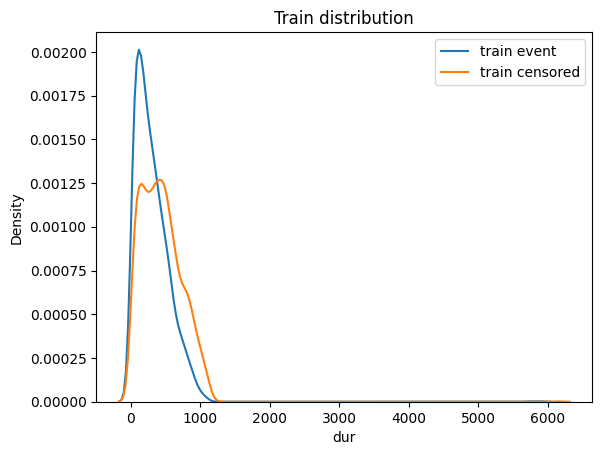

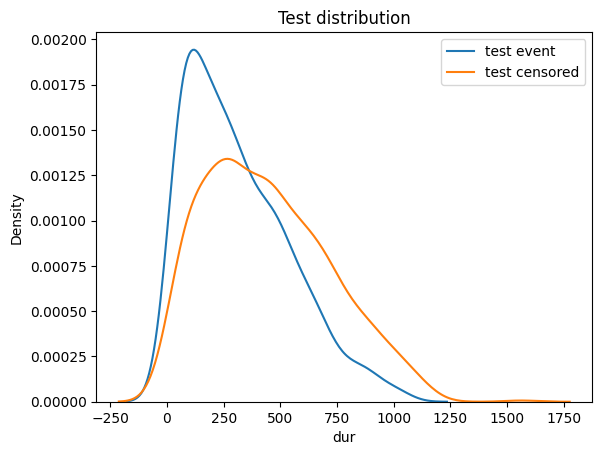

Train events: event
0    3382
1    2767
Name: count, dtype: int64
Test events: event
0    845
1    778
Name: count, dtype: int64


In [8]:
plt.figure()
sns.kdeplot(train_df[train_df["event"]==1]["dur"], label="train event")
sns.kdeplot(train_df[train_df["event"]==0]["dur"], label="train censored")
plt.legend()
plt.title("Train distribution")
plt.show()

plt.figure()
sns.kdeplot(test_df[test_df["event"]==1]["dur"], label="test event")
sns.kdeplot(test_df[test_df["event"]==0]["dur"], label="test censored")
plt.legend()
plt.title("Test distribution")
plt.show()

print("Train events:", train_df["event"].value_counts())
print("Test events:", test_df["event"].value_counts())


In [9]:
# importlib.reload(models.cox_model)

print(train_df.columns)

features = [c for c in train_df.columns 
            if c not in ["name", "entry", "time", "event", "dur", "episode_col"]]
print(features)

cols_for_model = ["name", "entry", "time", "event"] + features
train_model_df = train_df[cols_for_model].copy()


model = CoxModel(features=features)
model.fit(train_model_df)

Index(['name', 'episode_col', 'entry', 'dur', 'event', 'age',
       'time_since_last_arrest', 'average_dur_custody', 'time'],
      dtype='object')
['age', 'time_since_last_arrest', 'average_dur_custody']


model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
entry col,'entry'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-20405.07
time fit was run,2026-02-21 03:02:20 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>


In [10]:
train_df["dur"].describe()

count    6149.000000
mean      381.495853
std       289.923100
min         1.000000
25%       159.000000
50%       336.000000
75%       547.000000
max      6141.000000
Name: dur, dtype: float64

In [11]:
survival_test = get_y(
    cens=test_cens,
    time=test_df["dur"] - test_df["entry"],
    competing=False
)

In [12]:
test_df

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0


In [13]:
from lifelines.utils import concordance_index
#times = np.linspace(0, train_df["dur"].max(), 200)
horizon = np.quantile(train_df["dur"], 0.95)
times = np.linspace(0, 1500, 200)

test_features = test_df.drop(columns=["time", "event"])
predictions = model.predict_survival(test_features, times)
#predictions = model.predict_survival(test_df, times)
estimate = predictions.values

print("Estimate shape:", estimate.shape)
print("Test size:", len(test_df))

ibs_metric = IBSMetric()
mean_ibs, ibs_by_time = ibs_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)

print(mean_ibs)

auprc_metric = AUPRCMetric()
auprc = auprc_metric.compute(
    survival_train,
    survival_test,
    estimate,
    times
)
print("AUPRC:", np.mean(auprc))

ci_metric = concordance_index(
    test_df["dur"],
    np.trapz(predictions.values, times, axis=1),
    test_cens
)
print("Concordance Index:", ci_metric)

Estimate shape: (1623, 200)
Test size: 1623
0.12840433084885566
AUPRC: 0.5989779098707513
Concordance Index: 0.7466311236238385


In [14]:
test_df

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0


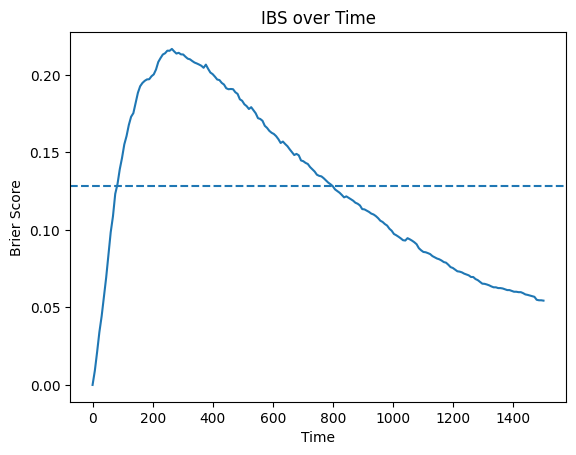

In [15]:
plt.plot(times, ibs_by_time)
plt.axhline(y=mean_ibs, linestyle="--")
plt.title("IBS over Time")
plt.xlabel("Time")
plt.ylabel("Brier Score")
plt.show()

In [16]:
from survivors import metrics
test_df_results = test_df[["name", "episode_col", "dur", "event"]].copy()

test_df_results["dur"] = test_df["dur"] - test_df["entry"]

test_df_results["ibs"] = metrics.ibs(
            survival_train=survival_train,
            survival_test=survival_test,
            estimate=estimate,
            times=times,
            axis=0
        )
test_df_results["auprc"] = metrics.auprc(
            survival_train=survival_train,
            survival_test=survival_test,
            estimate=estimate,
            times=times,
            axis=0
        )

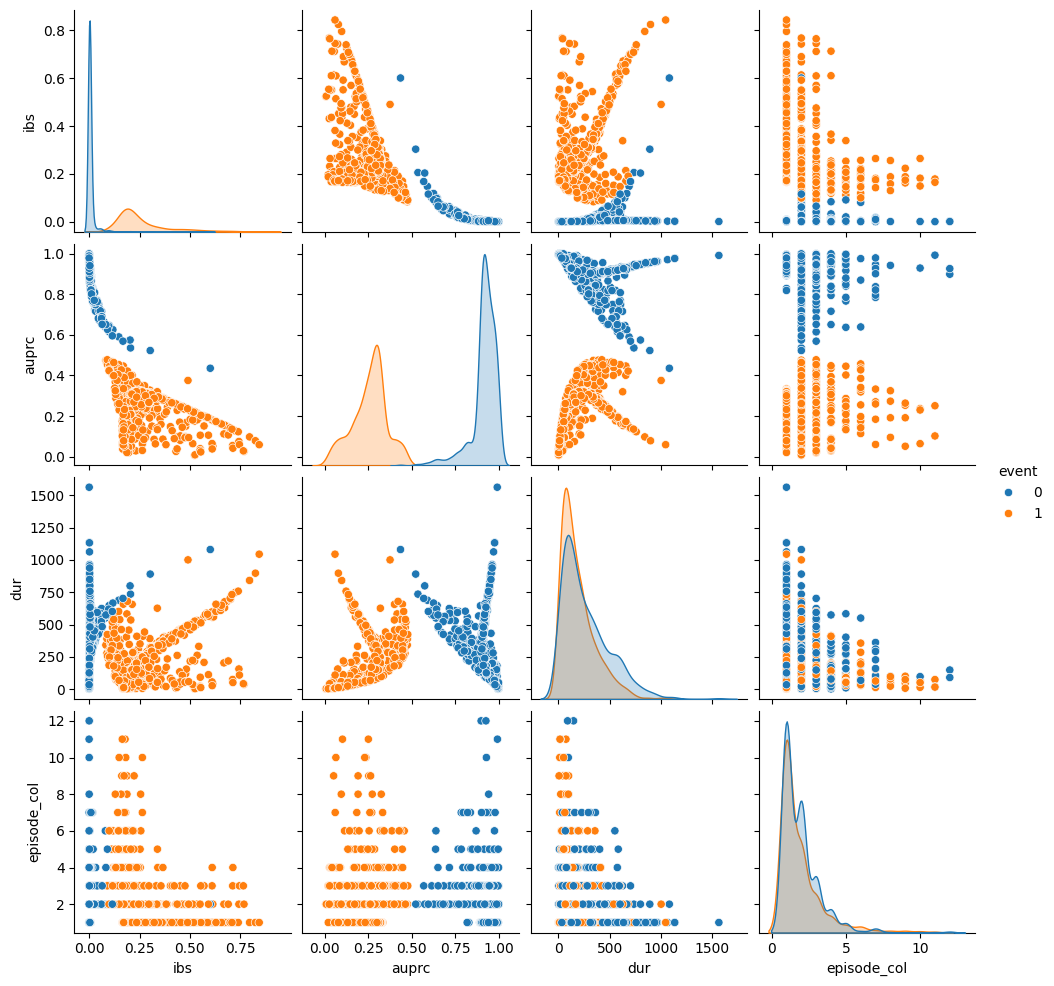

In [17]:
# sns.scatterplot(x="episode_col", y="auprc", data=test_df_results)
sns.pairplot(test_df_results, vars=["ibs", "auprc", "dur", "episode_col"], hue="event")

In [18]:
test_df_results[test_df_results["episode_col"] >= 8].round(3)
# test_df["dur"].describe()

,name,episode_col,dur,event,ibs,auprc
216,brandon ross,8,47.0,1,0.188,0.192
217,brandon ross,9,47.0,1,0.188,0.192
218,brandon ross,10,67.0,1,0.182,0.237
219,brandon ross,11,74.0,1,0.178,0.251
220,brandon ross,12,148.0,0,0.001,0.898
592,eric redmond,8,23.0,1,0.256,0.095
593,eric redmond,9,100.0,1,0.223,0.253
594,eric redmond,10,14.0,1,0.264,0.065
595,eric redmond,11,18.0,0,0.000,0.992
770,jason jaigobin,8,99.0,0,0.000,0.942


<Axes: xlabel='episode_col', ylabel='ibs'>

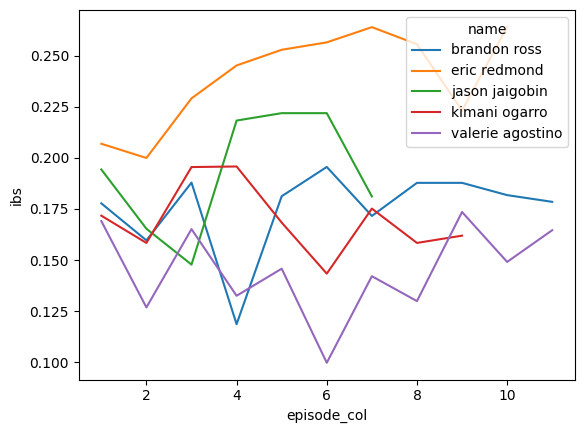

In [19]:
freq_name = test_df_results.query("episode_col >= 8")["name"].unique()
sns.lineplot(x="episode_col", y="ibs", hue="name",
                data=test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)"))

<Axes: xlabel='episode_col'>

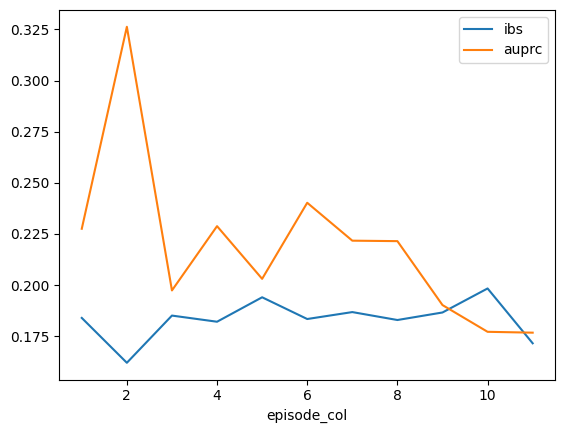

In [20]:
test_df_results.query(f"name.isin({list(freq_name)}) and (event == 1)").groupby("episode_col")[["ibs", "auprc"]].mean().plot()

In [ ]:
# tr_pred = 1 - model.predict_survival(train_df, times).values.T
tr_pred = model.predict_cumulative_hazard(train_df, times)
tr_max = np.quantile(tr_pred.max(), 0.95)

# pred = 1 - model.predict_survival(test_df, times).values.T
# test_df.drop_duplicates(["name"], keep='first')
pred = model.predict_cumulative_hazard(test_df, times)
# pred[:] = train_df.groupby("name")["event"].sum().mean()  // baseline случай фиксированного числа событий
print("pred shape:", pred.shape)
print("len(test_df):", len(test_df))
metric = RecurrentCountError()

recurrent_error = metric.compute(
    survival_train=None,
    survival_test=test_df,
    estimate=pred / tr_max,
    times=times
)

mean_events = test_df.groupby("name")["event"].sum().mean()
print("Mean event =", mean_events)
print("Integrated cumulative event error:", recurrent_error)

pred shape: (200, 1623)
len(test_df): 1623
Mean event = 0.9207100591715977
Integrated cumulative event error: 0.2867342182519552


In [35]:
pred

,0,1,2,3,4,5,8,10,11,12,...,1612,1613,1614,1616,1617,1618,1619,1620,1621,1622
0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7.537688,0.000513,0.003633,0.004160,0.002528,0.000618,0.001288,0.003555,0.000977,0.001171,0.001779,...,0.001021,0.000778,0.004960,0.001759,0.000288,0.004592,0.000637,0.002813,0.003357,0.000427
15.075377,0.001491,0.010560,0.012090,0.007349,0.001796,0.003743,0.010332,0.002840,0.003404,0.005172,...,0.002967,0.002261,0.014417,0.005113,0.000837,0.013348,0.001851,0.008178,0.009757,0.001240
22.613065,0.002788,0.019749,0.022612,0.013744,0.003358,0.007001,0.019323,0.005312,0.006367,0.009674,...,0.005549,0.004228,0.026963,0.009562,0.001566,0.024964,0.003463,0.015294,0.018248,0.002319
30.150754,0.003865,0.027374,0.031343,0.019051,0.004655,0.009704,0.026784,0.007362,0.008825,0.013409,...,0.007692,0.005861,0.037373,0.013254,0.002170,0.034603,0.004800,0.021200,0.025294,0.003215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469.849246,0.283391,2.007274,2.298296,1.396941,0.341349,0.711592,1.964007,0.539870,0.647145,0.983233,...,0.564047,0.429753,2.740516,0.971890,0.159130,2.537379,0.351942,1.554533,1.854780,0.235754
1477.386935,0.289903,2.053402,2.351113,1.429044,0.349194,0.727945,2.009141,0.552276,0.662016,1.005828,...,0.577010,0.439629,2.803495,0.994225,0.162787,2.595690,0.360029,1.590257,1.897404,0.241172
1484.924623,0.291038,2.061443,2.360319,1.434639,0.350561,0.730795,2.017008,0.554439,0.664609,1.009767,...,0.579269,0.441351,2.814472,0.998118,0.163424,2.605853,0.361439,1.596484,1.904833,0.242116
1492.462312,0.291038,2.061443,2.360319,1.434639,0.350561,0.730795,2.017008,0.554439,0.664609,1.009767,...,0.579269,0.441351,2.814472,0.998118,0.163424,2.605853,0.361439,1.596484,1.904833,0.242116


In [33]:
test_df.drop_duplicates(["name"], keep='first')

,name,episode_col,entry,dur,event,age,time_since_last_arrest,average_dur_custody,time
0,aaron hammond,1,0.0,699.0,0,25,688.0,11.0,699.0
1,aaron villacampa,1,0.0,107.0,0,26,106.0,1.0,107.0
2,abraham ballestas,1,0.0,35.0,0,52,34.0,1.0,35.0
3,acie canteen,1,0.0,215.0,0,27,214.0,1.0,215.0
4,adam gillstrap,1,0.0,630.0,0,35,628.0,2.0,630.0
...,...,...,...,...,...,...,...,...,...
1618,zachary payton,1,0.0,34.0,0,28,33.0,1.0,34.0
1619,zachary whalen,1,0.0,634.0,0,24,632.0,2.0,634.0
1620,zaheer khan,1,0.0,184.0,0,26,183.0,1.0,184.0
1621,zhivago walker,1,0.0,126.0,0,30,125.0,1.0,126.0
